# Assignment 1

Consider two Gaussian distributions whose parameters are given as follows:
\begin{equation}
\begin{split}
\mu_1 = \begin{bmatrix} 3 \\ 1 \end{bmatrix}, & \quad \Sigma_1 = \begin{bmatrix} 1 & 2 \\ 2 & 5 \end{bmatrix}, \\
\mu_2 = \begin{bmatrix} 1 \\ 3 \end{bmatrix}, & \quad \Sigma_2 = \begin{bmatrix} 1 & 2 \\ 2 & 5 \end{bmatrix}.
\end{split}
\end{equation}


## (1) Plot

Show the scatter plot of bi-variate random numbers (2-d samples) $X$ generated from the above two distributions (use different colors or markers so that the two distributions can be distinguished).

* Use `ax.set_aspect('equal', adjustable='box')` to equalize the x- and y-scales. See https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_aspect.html for details.
* You can use [`numpy.random.multivariate_normal()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.multivariate_normal.html?highlight=multivariate#numpy.random.multivariate_normal) to generate random samples.

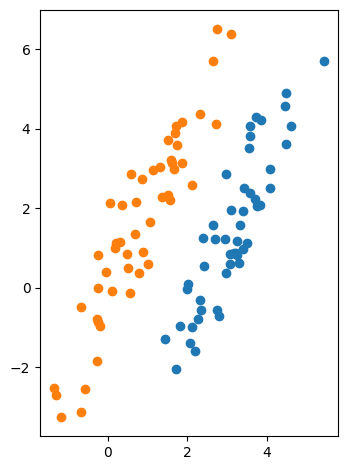

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import multivariate_normal

N=100
#縦に結合
X = np.vstack( [
                multivariate_normal([3, 1], [[1, 2], [2, 5]], size=N//2),
                multivariate_normal([1, 2], [[1, 2], [2, 5]], size=N//2)
               ])
#横に結合
Y = np.hstack( [np.zeros((N//2, 1)), np.ones((N//2, 1))])

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.scatter(X[:N//2, 0], X[:N//2, 1])
ax.scatter(X[N//2:, 0], X[N//2:, 1])
ax.set_aspect('equal', adjustable='box')
fig.tight_layout()
plt.show()


In [53]:
print(multivariate_normal([3, 1], [[1, 2], [2, 5]], size=N//2))
               

[[ 3.54542102  1.02303651]
 [ 4.14550276  3.84166372]
 [ 3.48243092  2.48145128]
 [ 3.34646654  0.84526027]
 [ 2.17030294  1.17798744]
 [ 3.16409568  2.45702008]
 [ 3.46949099  1.68330748]
 [ 3.43423241  0.8341675 ]
 [ 3.41664105  2.40929282]
 [ 3.71304963  2.04862299]
 [ 1.6249809  -1.54139053]
 [ 2.35648103 -0.57877261]
 [ 4.32066432  4.86623717]
 [ 1.71652474 -2.29554836]
 [ 1.48776953 -2.38132769]
 [ 5.58851034  6.18944303]
 [ 2.49212466  1.09549012]
 [ 2.60762305  0.28638693]
 [ 2.21319982 -1.52012035]
 [ 2.44414981  0.24797953]
 [ 2.91711955  1.75368141]
 [ 2.47427162  0.6086723 ]
 [ 3.86702526  2.66047839]
 [ 2.60668383 -0.27568196]
 [ 2.79359703 -1.69146241]
 [ 3.54122054  0.68224765]
 [ 0.1297021  -6.81609886]
 [ 4.17706641  3.2863568 ]
 [ 2.34611195  0.04233159]
 [ 2.50409951  0.98012639]
 [ 3.74236326  3.38912829]
 [ 2.68690996 -0.4526285 ]
 [ 1.69939541 -2.67975716]
 [ 2.730299    0.87530023]
 [ 3.70658408  2.01851258]
 [ 3.32904432  2.10287746]
 [ 3.26733167  3.06327942]
 

In [54]:
print("X.shape" , X.shape)

X.shape (100, 2)


In [55]:
print("Y.shape",  Y.shape)

Y.shape (50, 2)


## (2) PCA

Apply PCA to the 2-d samples generated in (1) by assuming two distributions as a single sample set. Draw the 1st principal axis on the scatter plot in (1). (Do not use built-in / library function of PCA, such as `sklearn.decomposition.PCA`)

* Use `ax.set_aspect('equal', adjustable='box')` to equalize the x- and y-scales as done in the above.
* `print()` the calculated axis orientation (the slope).


m [1.97334044 1.49792117]
(2, 2)
eigenvalues [1.30471755 5.44443493]
eigenvectors [[-0.87149317 -0.49040765]
 [ 0.49040765 -0.87149317]]
min_idx 0
eigenvector_PCA_max [-0.49040765 -0.87149317]


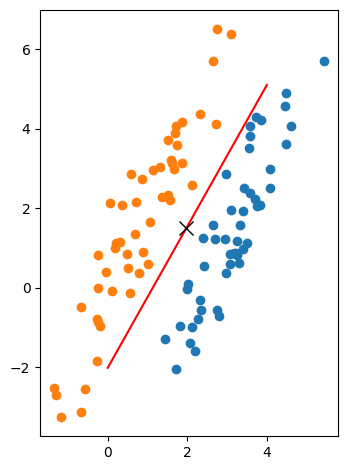

In [56]:
# Implement by yourself


#mは平均ベクトル
m = np.mean(X, axis=0)

X_centered = X - m

#print("X_1",X_1)
print("m",m)
#Sは共分散行列
S = 1/N * X_centered.T @ X_centered

print(S.shape)
eigenvalues_PCA, eigenvectors_PCA = np.linalg.eig(S)
#print("eigenvalues", eigenvalues)  

print("eigenvalues", eigenvalues_PCA)
print("eigenvectors", eigenvectors_PCA) 
min_idx = np.argmin(eigenvalues_PCA)
print("min_idx", min_idx)
max_idx = np.argmax(eigenvalues_PCA)
eigenvector_PCA_max = eigenvectors_PCA[:, max_idx]

#固有ベクトルを正規化
eigenvector_PCA_max = eigenvector_PCA_max / np.sqrt(eigenvector_PCA_max.T @ eigenvector_PCA_max)

a = eigenvector_PCA_max[1] / eigenvector_PCA_max[0]

print("eigenvector_PCA_max", eigenvector_PCA_max)

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.scatter(X[:N//2, 0], X[:N//2, 1])
ax.scatter(X[N//2:, 0], X[N//2:, 1])


x = np.linspace(0, 4, 100)
y1 = a * (x - m[0]) + m[1]
plt.plot(x, y1, color='red', )
plt.plot(m[0], m[1], 'x', c = "black", markersize=10)
fig.tight_layout()
ax.set_aspect('equal', adjustable='box')
plt.show()


To double-check the optimality of the axis given by PCA, plot the variance $\tilde{\sigma}^2$ at each axis orientation $\theta = [0:\pi]$.  Also `print()` the value of $\theta$ where $\tilde{\sigma}^2$ is maximized.

C:\Users\i0530\AppData\Local\Temp\ipykernel_26424\2937801854.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


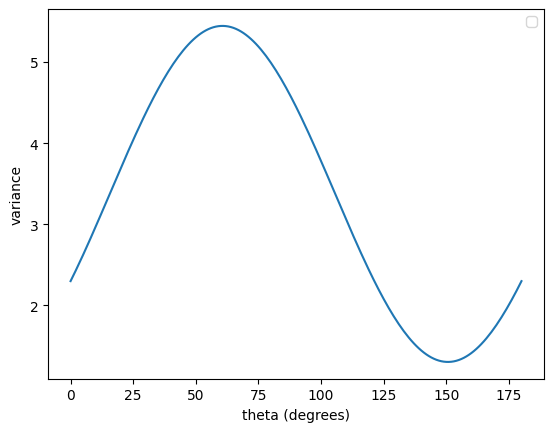

theta = 61


In [57]:
# Implement by yourself
U = np.zeros((2, 181))


for i in range(181):
    U[0,i] = np.cos(i * np.pi / 180)
    U[1,i] = np.sin(i * np.pi / 180)

var = np.zeros(U.shape[1])
for i in range(U.shape[1]): 
    #print(U[:, i])
    #varは各角度の直線に対する分散
    var[i] = (U[:, i].T @ S @ U[:, i])
    #print(i,var[i])

#print(var[180])

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.plot(np.arange(181), var, )
ax.set_xlabel("theta (degrees)")
ax.set_ylabel("variance")

ax.legend()
plt.show()
theta = np.argmax(var)
print("theta =",theta)


## (3) LDA

Apply Fisher LDA to the 2-d samples generated in (1) by assuming the two distributions are two different classes. Draw the calculated axis on the scatter plot. (Do not use built-in function of LDA, such as `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`)

* Use `ax.set_aspect('equal', adjustable='box')` to equalize the x- and y-scales as done in the above.


S_w [[ 92.09920479 184.11372099]
 [184.11372099 444.50888704]]
S_b [[137.93261204  -7.18761771]
 [ -7.18761771   0.37454412]]
Eigenvalues of LDA: [ 9.08861889e+00 -2.77555756e-17]
Eigenvectors of LDA: [[ 0.92329088  0.05203903]
 [-0.38410148  0.99864505]]
eigenvector_LDA_max [ 0.92329088 -0.38410148]


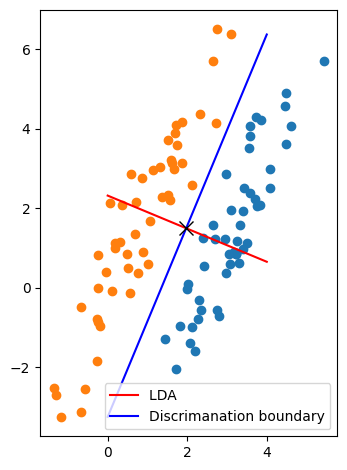

In [58]:
# Implement by yourself
X_LDA_centerd = np.zeros(X.shape)
S_w = np.zeros((2, 2))

m_1 = np.mean(X[:N//2], axis=0)  
m_2 = np.mean(X[N//2:], axis=0)

for i in range(2):
    X_LDA_centerd[:N//2, i] = X[:N//2, i] - m_1[i]
    X_LDA_centerd[N//2:, i] = X[N//2:, i] - m_2[i]

S_w = np.dot(X_LDA_centerd[:N//2].T, X_LDA_centerd[:N//2]) + np.dot(X_LDA_centerd[N//2:].T, X_LDA_centerd[N//2:])

S_b = N/2*(m_1 - m).reshape(2,1) @ (m_1 - m).reshape(2,1).T + N/2*(m_2 - m).reshape(2,1) @ (m_2 - m).reshape(2,1).T
print("S_w", S_w)
print("S_b", S_b)

#print("m", m.reshape(1, 2))

M = np.linalg.inv(S_w) @ S_b

eigenvalues_LDA, eigenvectors_LDA = np.linalg.eig(M)
print("Eigenvalues of LDA:", eigenvalues_LDA)
print("Eigenvectors of LDA:", eigenvectors_LDA) 
eigenvector_LDA_max = eigenvectors_LDA[:, np.argmax(eigenvalues_LDA)]

#固有ベクトルを正規化
eigenvector_LDA_max = eigenvector_LDA_max / np.sqrt(eigenvector_LDA_max.T @ eigenvector_LDA_max)
print("eigenvector_LDA_max", eigenvector_LDA_max)   

b = eigenvector_LDA_max[1] / eigenvector_LDA_max[0]

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.scatter(X[:N//2, 0], X[:N//2, 1])
ax.scatter(X[N//2:, 0], X[N//2:, 1])


x = np.linspace(0, 4, 100)
y2 = b * (x - m[0]) + m[1]
y2_vertical = -1/b * (x - m[0]) + m[1]

plt.plot(x, y2, color='red', label ="LDA ")

plt.plot(x, y2_vertical, color='blue', label="Discrimanation boundary")


plt.plot(m[0], m[1], 'x', c = "black", markersize=10)
fig.tight_layout()
ax.set_aspect('equal', adjustable='box')

ax.legend()
plt.show()


To double-check the optimality of the axis given by LDA, plot $\tilde{S}_b / \tilde{S}_w$ at each axis orientation $\theta = [0:\pi]$.  Also `print()` the value of $\theta$ where $\tilde{S}_b / \tilde{S}_w$ is maximized.

C:\Users\i0530\AppData\Local\Temp\ipykernel_26424\1318166423.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


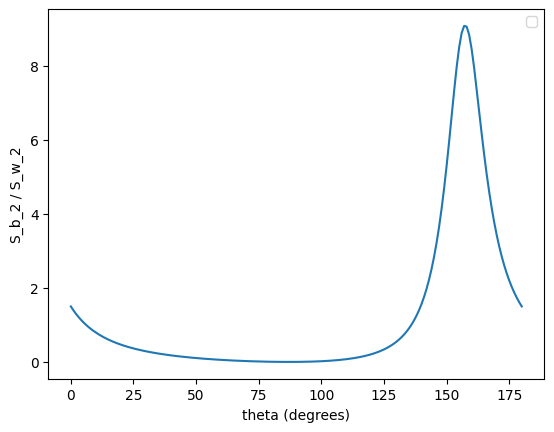

theta = 157


In [59]:
# Implement by yourself

S_w_2 = np.zeros(U.shape[1])
S_b_2 = np.zeros(U.shape[1])
W = np.zeros(S_w_2.shape)
#print(W)
#print(S_w_2.shape)
for i in range(181):
    U[0,i] = np.cos(i * np.pi / 180)
    U[1,i] = np.sin(i * np.pi / 180)

    S_w_2[i] = U[:,i].T @ S_w @ U[:,i]
    S_b_2[i] = U[:,i].T @ S_b @ U[:,i]
    W[i] = S_b_2[i] / S_w_2[i]

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.plot(np.arange(181), W, )
ax.set_xlabel("theta (degrees)")
ax.set_ylabel("S_b_2 / S_w_2")

ax.legend()
plt.show()
theta_2 = np.argmax(W)
print("theta =",theta_2)


    

## (4) Histograms

Show the 1-d histograms of the sample data transformed by the calculated axes in (2) and (3).
* You can use [`numpy.histogram()`](https://numpy.org/doc/stable/reference/generated/numpy.histogram.html) and/or [`matplotlib.pyplot.hist()`](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.hist.html#matplotlib-pyplot-hist).

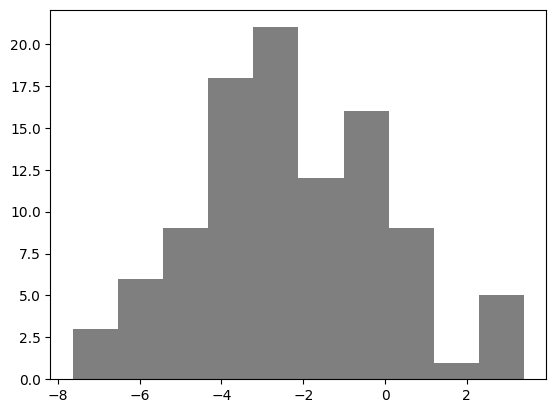

In [60]:
# Implement by yourself
#各点をy1,y2に射影する　座標はy1,y2

from matplotlib.pyplot import axes


Y_PCA = X @ eigenvector_PCA_max
Y_LDA = X @ eigenvector_LDA_max
#print(Y_PCA.shape)
#print(Y_LDA.shape)

plt.hist(Y_PCA, alpha=0.5, label="PCA", color = 'Black')
plt.grid = True
#print("Y_PCA", Y_PCA)
#print("Y_LDA", Y_LDA)


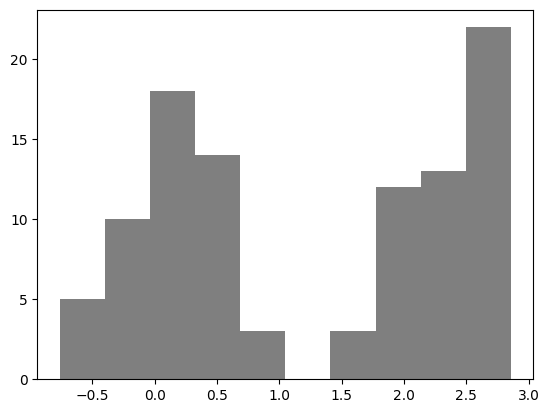

In [61]:
plt.hist(Y_LDA, alpha=0.5, label="LDA", color = "Black")
plt.grid= True

# (5) Discussions

PCAの目的は、データの分散を最大化することで、情報の損失を最小限に抑えた次元削減を行うことです。今回、射影後の分散が最大となるように新たな軸を定めることで、元のデータの特徴が最大限保持されていることが確認できました。相関のあるデータに対して、データの広がりが最も大きい方向に軸が設定されたことは、PCAの妥当性を視覚的にも裏付けています。また、直線の偏角を0°から180°まで変化させて分散を計算した際、分散が最大となる偏角とグラフ上の主成分軸の方向が一致したことも、算出した軸の妥当性を示しています。<br><br>
一方、LDAの目的は、クラス間の分離能（クラス分離性）を最大限に保持した上での次元削減です。そのため、射影後の軸上で各クラスのデータが明確に区別できる必要があります。今回LDAで定めた軸は、2クラスの境界線におおよそ垂直な方向を向いており、視覚的にも妥当な結果となりました。 さらに、フィッシャーの線形判別基準であるクラス間分散とクラス内分散の比（$\tilde{S}_b / \tilde{S}_w$）を最大化する偏角が、実際に定めた軸の偏角と概ね一致していることからも、軸の選定が適切であったと考察できます。<br><br>
ヒストグラムによる評価では、PCAは1次元に圧縮した後もデータのばらつき（広がり）が維持されていることが見て取れます。LDAにおいては、ヒストグラムの分布が重ならず、谷（へこみ）が生じている部分を確認できました。この部分を決定境界とすることで高い識別精度が期待できるため、LDAによる軸の抽出は妥当であると結論付けられます。







# Submit your ipynb

1. Click [Runtime]->[Restart and run all] to make sure that the notebook can run successfully from scratch.
2. Download the notebook as `ipynb` by [File]->[Download] menu.
3. Upload the downloaded `ipynb` to PandA.

